# Experiment 5 : Sensitivity Analysis

**Drug Modeled:** Gefitinib

**Condition Tested:** Comparing effects of all parameters along the pathway

**Research Question:** Which parameters most strongly influence proliferation?

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Diffusion coefficient array
D_values = np.logspace(-7, -6, 10)

# Number of spatial points
nx = 200

# Tumor depth range
x = np.linspace(0, 0.2, nx) # cm, (0-2 mm)

# EGFR Inhibition Hill coefficient
n = 1

# Literature IC_50 value, concentration of gefitinib to achieve 50% inhibition of EGFR
ic_50 = 0.3

# ERK activation rate constant
k_act = 0.1

# ERK deactivation rate constant
k_deact = 0.3

# Effective signal gain, balance between ERK activation/deactivation
alpha_erk = k_act / k_deact

# Proliferation Hill coefficient
m = 4

# Half-maximal ERK activity
K = 0.5

def diffusion_solver(D_base):
    # Tissue depth range (cm)
    L = 0.2             # 2 mm

    dx = x[1] - x[0]

    # Total simulation time (s)
    T = 3600            # 1 hour

    # Number of time steps
    nt = 15000

    dt = T / nt

    # Layer boundaries (cm)
    boundary_1 = 0.05   # 0.5 mm
    boundary_2 = 0.12   # 1.2 mm

    # Tumor density coefficient
    alpha_i = 0.2

    # Diffusion coefficients for each layer (cm^2/s)
    D1 = D_base             # Outer tumor region
    D2 = alpha_i * D_base   # Dense / diffusion-limited region
    D3 = D_base             # Deeper tumor region

    # Spatial diffusitivity profile
    D = np.full(nx, D1)

    D[x >= boundary_1] = D2
    D[x >= boundary_2] = D3

    # Constant drug source at vessel boundary
    C_source = 1.0

    # Saving buffer
    save_every = 25

    # Solving for spatial concentration profile
    C = np.zeros(nx)
    
    C[0] = C_source
    saved_profiles = []

    # Time-stepping loop
    for t in range(nt):
        C_new = C.copy()

        for i in range(1, nx - 1):
            # diffusitivies
            D_left = (D[i] + D[i-1]) / 2
            D_right = (D[i] + D[i+1]) / 2

            # diffusion fluxes
            J_left = -D_left * (C[i] - C[i-1]) / dx
            J_right = -D_right * (C[i+1] - C[i]) / dx

            # update concentration
            C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

        C = C_new

        # Re-apply source boundary condition
        C[0] = C_source

        if (t % save_every) == 0:
            saved_profiles.append(C.copy())
    
    C = np.array(saved_profiles)
    return C

def egfr_activity(C, IC50, n):
    A = 1 / (1 + (C / IC50) ** n)
    return A

def erk_activity(EGFR, alpha):
    ERK = alpha * EGFR
    return ERK

def proliferation(ERK, K, m):
    P = ERK ** m / (ERK ** m + K ** m)
    return P

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Solving average proliferation rates
prolif_avg_A = []

for D_base in D_values:
    C = diffusion_solver(D_base)
    EGFR = egfr_activity(C, ic_50, n)
    ERK = erk_activity(EGFR, alpha_erk)
    P = proliferation(ERK, K, m)
    prolif_avg_A.append(np.mean(P[-1, :]))

# See if this can run faster!

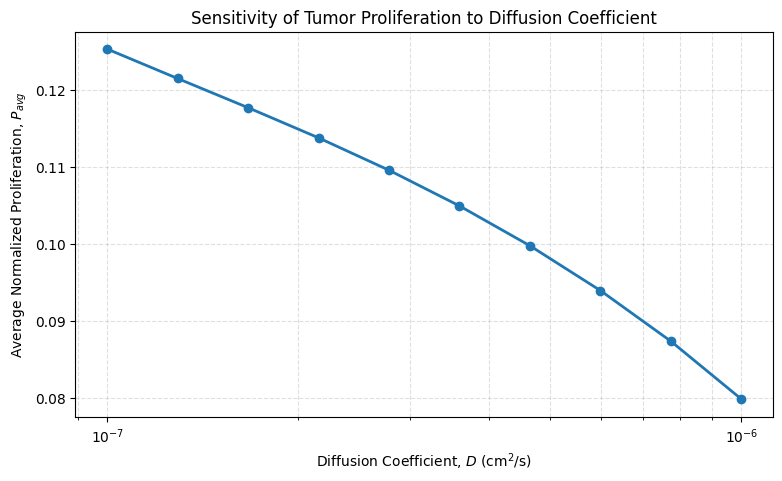

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(D_values, prolif_avg_A, marker='o', linewidth=2)

plt.xscale('log')

plt.xlabel(r'Diffusion Coefficient, $D$ (cm$^2$/s)')
plt.ylabel(r'Average Normalized Proliferation, $P_{avg}$')
plt.title('Sensitivity of Tumor Proliferation to Diffusion Coefficient')

plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.show()

## Figure 5A

**Figure 5A.** Sensitivity of predicted average tumor cell proliferation ($P_{avg}$) to the effective diffusion coefficient ($D_{eff}$) of gefitinib. The diffusion coefficient was varied over one order of magnitude while maintaining a constant heterogeneous tissue architecture. The average was computed from the final proliferation field. Increasing diffusion coefficients resulted in progressively lower average proliferation, indicating that improved drug transport enhances therapeutic efficacy by increasing intratumoral drug penetration.

### Observations

As the baseline diffusion coefficient increased, the average normalized proliferation decreased across the simulated tumor. The relationship was monotonic, with larger diffusion coefficients producing progressively greater reductions in proliferation. The negative slope indicates that enhanced molecular transport consistently improves the biological response predicted by the model.

### Interpretation

Increasing the diffusion coefficient allows gefitinib to penetrate more effectively through the heterogeneous tumor tissue, exposing a larger fraction of tumor cells to inhibitory drug concentrations. Consequently, a greater proportion of the EGFR signaling pathway is suppressed, resulting in reduced ERK activity and lower predicted proliferation rates. These findings demonstrate that drug transport properties influence not only spatial concentration profiles but also the overall therapeutic response of the tumor.

### Discussion

The sensitivity analysis identifies drug diffusion as a key determinant of treatment efficacy within the computational framework. Because the heterogeneous tissue architecture was preserved throughout the parameter sweep, the observed changes in proliferation are dependent on the intrinsic transport properties of gefitinib rather than changes in tumor structure. This highlights the importance of molecular diffusion in determining the extent of pathway inhibition achieved throughout the tumor.

From a biomedical perspective, these results suggest that therapeutic strategies which improve effective intratumoral drug transport (modifying molecular physicochemical properties, improving formulation or delivery methods, or reducing extracellular transport barriers) may substantially enhance treatment efficacy. More broadly, the analysis demonstrates the value of sensitivity analysis in systems biology by identifying diffusion as an influential model parameter whose variation propagates through transport, signaling, and proliferation to alter the predicted therapeutic response.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# IC50 array
ic_50_values = np.linspace(0.1, 0.6, 10)

# Diffusison coefficient
D = 5e-7

# Number of spatial points
nx = 200

# Tumor depth range
x = np.linspace(0, 0.2, nx) # cm, (0-2 mm)

# EGFR Inhibition Hill coefficient
n = 1

# ERK activation rate constant
k_act = 0.1

# ERK deactivation rate constant
k_deact = 0.3

# Effective signal gain, balance between ERK activation/deactivation
alpha_erk = k_act / k_deact

# Proliferation Hill coefficient
m = 4

# Half-maximal ERK activity
K = 0.5

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Solving average proliferation rates
prolif_avg_B = []

for ic_50 in ic_50_values:
    C = diffusion_solver(D)
    EGFR = egfr_activity(C, ic_50, n)
    ERK = erk_activity(EGFR, alpha_erk)
    P = proliferation(ERK, K, m)
    prolif_avg_B.append(np.mean(P[-1, :]))

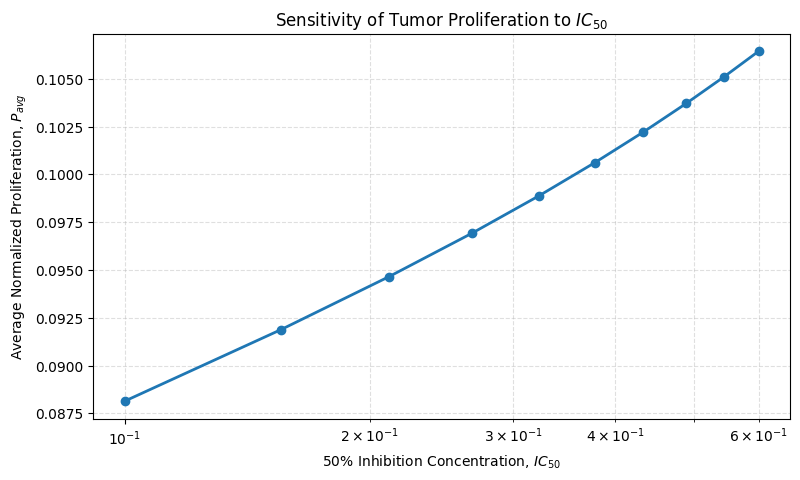

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(ic_50_values, prolif_avg_B, marker='o', linewidth=2)

plt.xscale('log')

plt.xlabel(r'50% Inhibition Concentration, $IC_{50}$')
plt.ylabel(r'Average Normalized Proliferation, $P_{avg}$')
plt.title(r'Sensitivity of Tumor Proliferation to $IC_{50}$')

plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.show()

## Figure 5B

**Figure 5B.** Sensitivity of predicted average tumor proliferation to the half-maximal inhibitory concentration ($IC_{50}$) of gefitinib. The $IC_{50}$ parameter was varied while all transport and signaling parameters remained fixed. Increasing $IC_{50}$ values resulted in progressively higher average proliferation, reflecting reduced EGFR inhibition as greater drug concentrations were required to achieve the same level of pathway suppression.

### Observations

As the $IC_{50}$ increased, the average normalized proliferation increased in a nonlinear manner. At lower $IC_{50}$ values, proliferation remained relatively low because gefitinib effectively inhibited EGFR signaling even at modest concentrations. As $IC_{50}$ increased, proliferation rose more rapidly, indicating that reductions in drug potency had an increasingly pronounced effect on the predicted therapeutic response.

### Interpretation

The nonlinear increase arises from the Hill relationship governing EGFR inhibition. Increasing $IC_{50}$ shifts the inhibition curve toward higher drug concentrations, reducing receptor inhibition throughout much of the tumor. Consequently, EGFR activity remains elevated across larger regions of the tissue, leading to increased ERK signaling and higher predicted proliferation. Because this relationship is inherently nonlinear, equivalent increases in $IC_{50}$ do not produce equivalent changes in proliferation, particularly near the concentration range where gefitinib transitions from effective to ineffective inhibition.

### Discussion

This sensitivity analysis demonstrates that therapeutic efficacy depends not only on drug transport but also on the intrinsic potency of the inhibitor. Whereas the diffusion coefficient determines how effectively gefitinib reaches tumor cells, the $IC_{50}$ determines how efficiently those local drug concentrations translate into EGFR inhibition. The nonlinear response observed here suggests that relatively small reductions in drug potency—such as those resulting from resistance-associated EGFR mutations or altered drug-target interactions—can substantially diminish treatment efficacy once the $IC_{50}$ approaches the concentration range achieved within the tumor. These findings emphasize that optimizing targeted therapies requires consideration of both pharmacokinetic factors governing drug delivery and pharmacodynamic factors governing receptor inhibition.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# EGFR Inhibition Hill coefficient (n) array
n_values = np.linspace(0.5, 4.0, 10)

# Diffusison coefficient
D = 5e-7

# Number of spatial points
nx = 200

# Tumor depth range
x = np.linspace(0, 0.2, nx) # cm, (0-2 mm)

# Literature IC_50 value, concentration of gefitinib to achieve 50% inhibition of EGFR
ic_50 = 0.3

# ERK activation rate constant
k_act = 0.1

# ERK deactivation rate constant
k_deact = 0.3

# Effective signal gain, balance between ERK activation/deactivation
alpha_erk = k_act / k_deact

# Proliferation Hill coefficient
m = 4

# Half-maximal ERK activity
K = 0.5

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Solving average proliferation rates
prolif_avg_C = []

for n in n_values:
    C = diffusion_solver(D)
    EGFR = egfr_activity(C, ic_50, n)
    ERK = erk_activity(EGFR, alpha_erk)
    P = proliferation(ERK, K, m)
    prolif_avg_C.append(np.mean(P[-1, :]))

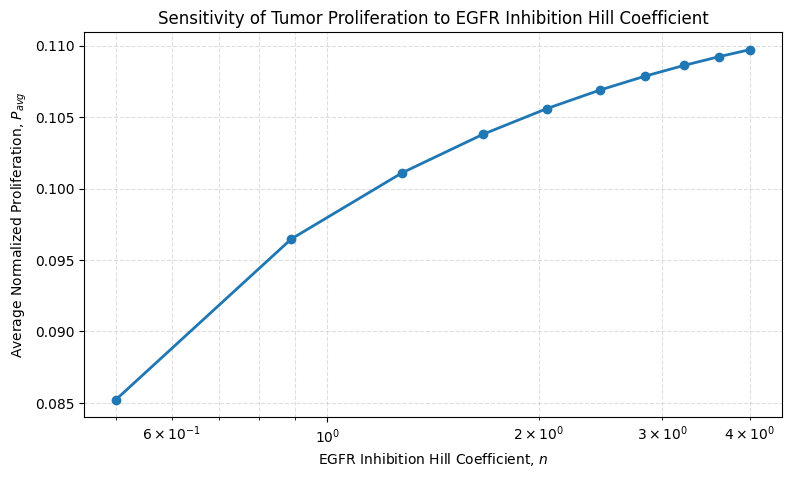

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(n_values, prolif_avg_C, marker='o', linewidth=2)

plt.xscale('log')

plt.xlabel(r'EGFR Inhibition Hill Coefficient, $n$')
plt.ylabel(r'Average Normalized Proliferation, $P_{avg}$')
plt.title(r'Sensitivity of Tumor Proliferation to EGFR Inhibition Hill Coefficient')

plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.show()

## Figure 5C

**Figure 5C.** Sensitivity of predicted average tumor proliferation to the EGFR inhibition Hill coefficient ($n$). The Hill coefficient was varied while maintaining constant diffusion, $IC_{50}$, and downstream signaling parameters. Increasing n resulted in a nonlinear increase in average proliferation, reflecting increasingly switch-like EGFR inhibition across the spatial drug concentration gradient.

### Observations

Average normalized proliferation increased with increasing Hill coefficient, although the rate of increase gradually diminished at higher values of $n$. The response was nonlinear, with the largest changes occurring between lower Hill coefficients and progressively smaller increases as the curve approached a plateau.

### Interpretation

The Hill coefficient controls the cooperativity of EGFR inhibition by gefitinib. As $n$ increases, the inhibition curve becomes steeper around the $IC_{50}$ threshold. Within the heterogeneous tumor, regions receiving drug concentrations below the $IC_{50}$ experience progressively weaker inhibition, while regions above the threshold remain strongly inhibited. Because a substantial portion of the tumor exists within this transition region, increasing the Hill coefficient shifts more tissue into either fully inhibited or minimally inhibited states, resulting in a modest increase in the overall predicted proliferation.

### Discussion

Unlike the diffusion coefficient $D$ and $IC_{50}$, which directly influence either drug delivery or inhibitor potency, the Hill coefficient governs the sharpness of the biological response to drug concentration. The relatively modest increase in proliferation observed during the sensitivity analysis suggests that the model is less sensitive to changes in cooperativity than to changes in transport or drug potency. This indicates that, within the simulated concentration range, altering how abruptly EGFR responds to gefitinib produces smaller changes in overall therapeutic efficacy than altering the amount of drug reaching the tumor or the concentration required for receptor inhibition. Consequently, the Hill coefficient primarily modulates the spatial transition between inhibited and uninhibited tumor regions rather than fundamentally changing the global treatment outcome.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# K (Proliferation sensitivity to ERK) array
k_values = np.linspace(0.2, 0.8, 10)

# Diffusison coefficient
D = 5e-7

# Number of spatial points
nx = 200

# Tumor depth range
x = np.linspace(0, 0.2, nx) # cm, (0-2 mm)

# Literature IC_50 value, concentration of gefitinib to achieve 50% inhibition of EGFR
ic_50 = 0.3

# EGFR Inhibition Hill Coefficient
n = 1

# ERK activation rate constant
k_act = 0.1

# ERK deactivation rate constant
k_deact = 0.3

# Effective signal gain, balance between ERK activation/deactivation
alpha_erk = k_act / k_deact

# Proliferation Hill coefficient
m = 4

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Solving average proliferation rates
prolif_avg_D = []

for K in k_values:
    C = diffusion_solver(D)
    EGFR = egfr_activity(C, ic_50, n)
    ERK = erk_activity(EGFR, alpha_erk)
    P = proliferation(ERK, K, m)
    prolif_avg_D.append(np.mean(P[-1, :]))

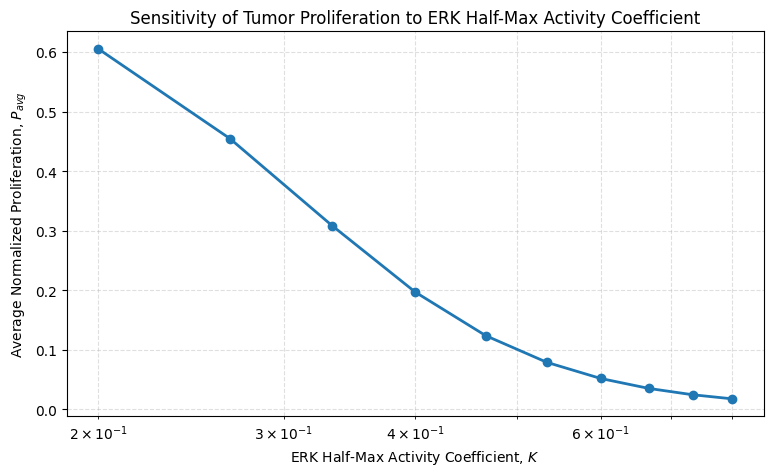

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(k_values, prolif_avg_D, marker='o', linewidth=2)

plt.xscale('log')

plt.xlabel(r'ERK Half-Max Activity Coefficient, $K$')
plt.ylabel(r'Average Normalized Proliferation, $P_{avg}$')
plt.title(r'Sensitivity of Tumor Proliferation to ERK Half-Max Activity Coefficient')

plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.show()

## Figure 5D

**Figure 5D.** Sensitivity of predicted average tumor proliferation to the ERK half-maximal activity coefficient ($K$). The parameter $K$, representing the ERK activity required to achieve half-maximal proliferation, was varied while all upstream transport and signaling parameters were held constant. Increasing $K$ produced a nonlinear decrease in average proliferation, indicating that higher signaling thresholds reduce the proliferative response despite identical ERK activity profiles.

### Observations

Average normalized proliferation decreased monotonically as the ERK half-maximal activity coefficient increased. The relationship was nonlinear, with the steepest decline occurring at lower values of $K$, followed by a gradual plateau as proliferation approached minimal values. This indicates that the model is particularly sensitive to changes in cellular response thresholds within the lower range of $K$.

### Interpretation

The parameter $K$ determines the level of ERK signaling required for cells to achieve half-maximal proliferation. Increasing $K$ makes cells less responsive to a given ERK signal, effectively raising the threshold required to activate downstream cell-cycle machinery. Consequently, identical ERK activity fields produce progressively lower proliferation rates as $K$ increases. The nonlinear behavior reflects the Hill kinetics governing the proliferation response, where the greatest sensitivity occurs near the transition between low and high pathway activation.

### Discussion

This sensitivity analysis demonstrates that downstream cellular response thresholds can substantially influence the predicted therapeutic outcome, independent of drug transport or receptor inhibition. Whereas the diffusion coefficient, $IC_{50}$, and Hill coefficient modify upstream processes governing drug delivery and EGFR inhibition, the parameter $K$ determines how intracellular signaling is translated into a biological decision to proliferate. The pronounced nonlinear decrease observed here suggests that modest increases in the ERK activity required for proliferation can produce substantial reductions in tumor growth. Biologically, this may represent strengthened cell-cycle checkpoints or reduced sensitivity of proliferative machinery to mitogenic signaling. These findings highlight that both upstream pharmacological processes and downstream signaling thresholds contribute to determining the overall efficacy of targeted therapies.

## Experiment 5 Summary

| Parameter | Minimum $P_{avg}$ | Maximum $P_{avg}$ | $\Delta P_{avg}$ |
|---|----------|-----------------|-------------|
| $D_{eff}$ | 0.0798 | 0.1253 | 0.0455 |
| $IC_{50}$ | 0.0881 | 0.1064 | 0.0183 |
| $n$ | 0.0852 | 0.1097 | 0.0245 |
| $K$ | 0.0172 | 0.6053 | 0.5881 |